In [1]:
import pyccl as ccl
import numpy as np
import pandas as pd
from IPython.display import Image, display

In [2]:
r_use = np.linspace(0.1, 100, 5)
print(r_use, r_use.shape, r_use[None, :].shape, r_use[:, None].shape, sep="\n")

[  0.1    25.075  50.05   75.025 100.   ]
(5,)
(1, 5)
(5, 1)


In [3]:
matrix = r_use[None, :] / r_use[:, None]
print(matrix)

df = pd.DataFrame(matrix)
# Format and add a color gradient (coolwarm or Blues)
df.style.format("{:.4f}").background_gradient(cmap="Blues")

[[1.00000000e+00 2.50750000e+02 5.00500000e+02 7.50250000e+02
  1.00000000e+03]
 [3.98803589e-03 1.00000000e+00 1.99601196e+00 2.99202393e+00
  3.98803589e+00]
 [1.99800200e-03 5.00999001e-01 1.00000000e+00 1.49900100e+00
  1.99800200e+00]
 [1.33288904e-03 3.34221926e-01 6.67110963e-01 1.00000000e+00
  1.33288904e+00]
 [1.00000000e-03 2.50750000e-01 5.00500000e-01 7.50250000e-01
  1.00000000e+00]]


,0,1,2,3,4
0,1.0000,250.7500,500.5000,750.2500,1000.0000
1,0.0040,1.0000,1.9960,2.9920,3.9880
2,0.0020,0.5010,1.0000,1.4990,1.9980
3,0.0013,0.3342,0.6671,1.0000,1.3329
4,0.0010,0.2508,0.5005,0.7503,1.0000


In [4]:
# display(
#     Image(
#         filename='code_exploration/numpy_broadcasting_to_matrix.png',
#           width=800
#           )
#     )

In [5]:
def show_images(nrow=1, ncol=2, images: list = [], **kwargs):

    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg

    def read_im(imname):
        return mpimg.imread(imname)

    # 1. Load your images
    imgs = {ii: read_im(name) for ii, name in enumerate(images)}

    # 2. Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(nrow, ncol, **kwargs)
    if np.ndim(axes) == 0:
        axes.imshow(imgs[0])
        axes.axis("off")  # Hide pixel grid lines and numbers
    else:
        for ii, ax in enumerate(axes.ravel()):
            # 3. Display the first image on the left axis
            ax.imshow(imgs[ii])
            ax.axis("off")  # Hide pixel grid lines and numbers
            # ax.set_title("Same array")  # Optional title

    # 5. Render the row cleanly
    plt.tight_layout()
    plt.show()


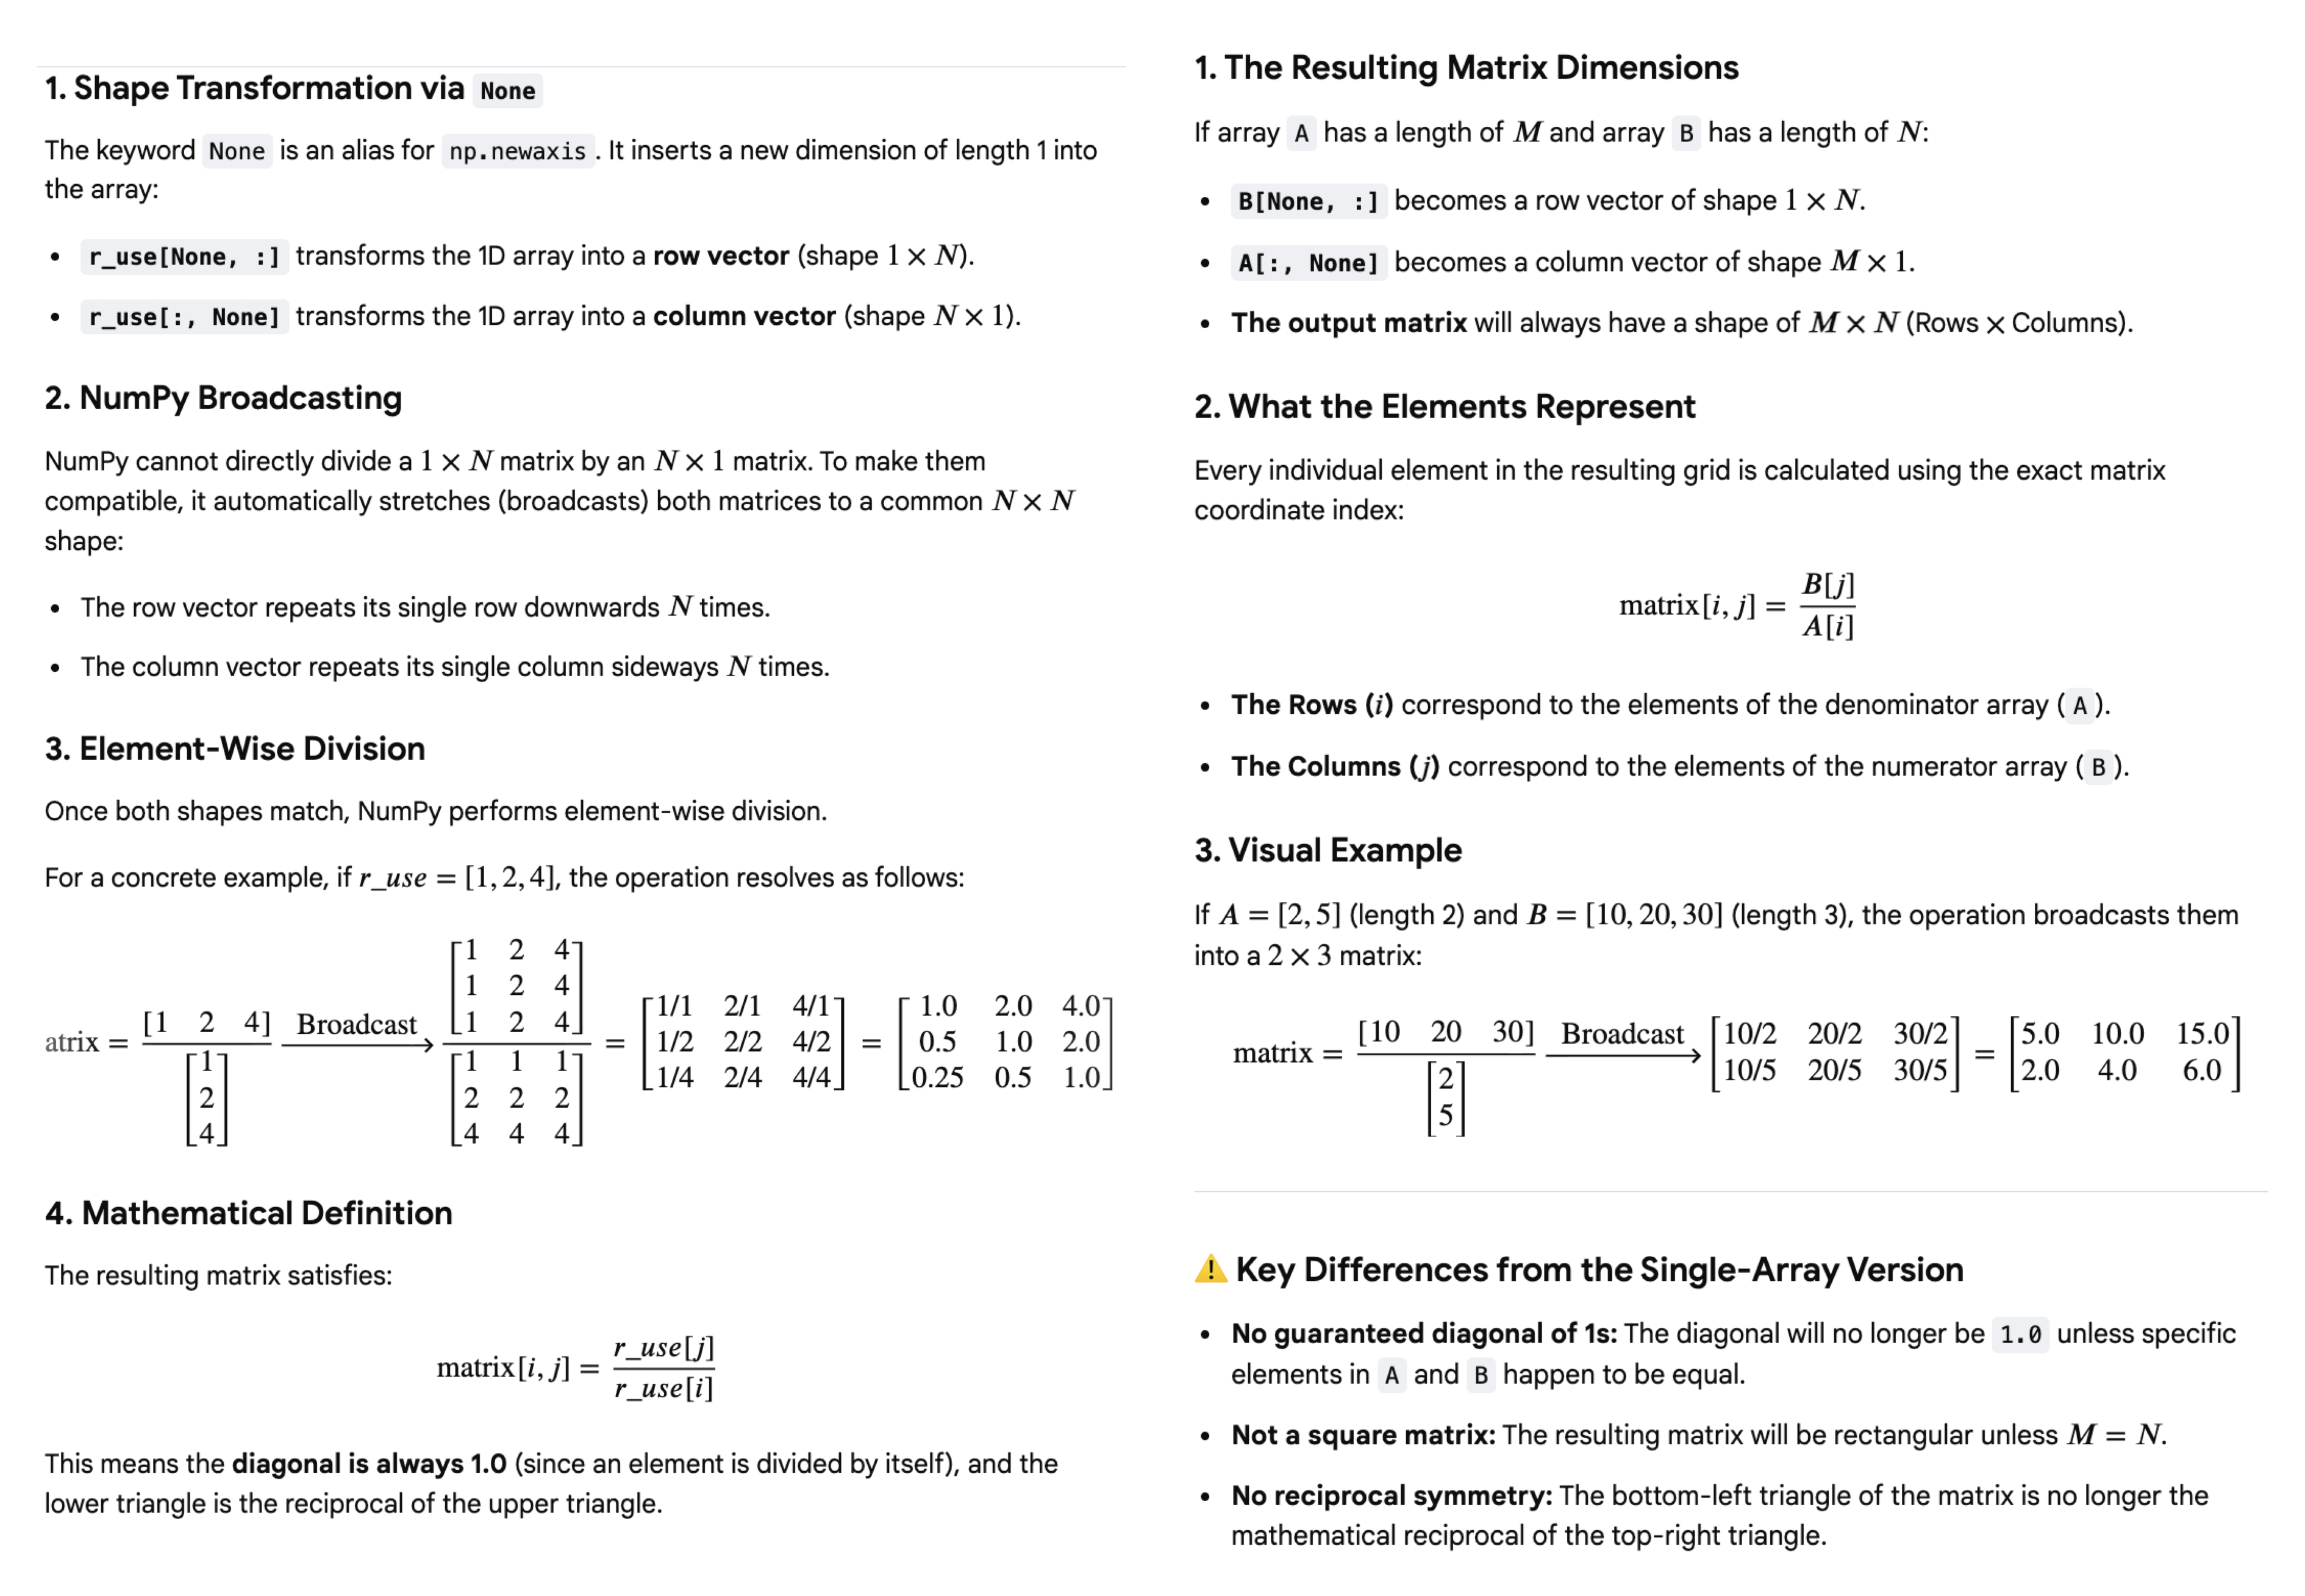

In [6]:
# 1. Load your images
images = [
    "code_exploration/numpy_broadcasting_to_matrix.png",
    "code_exploration/numpy_boadcasting_with_different_arrays.png",
]
show_images(1, 2, images=images, dpi=600)

Matrix operations happen at the level of values in the matrix grid

In [7]:
matrix / matrix

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [8]:
df = pd.DataFrame(matrix + 1)
# Format and add a color gradient (coolwarm or Blues)
df.style.format("{:.4f}").background_gradient(cmap="Blues")

,0,1,2,3,4
0,2.0000,251.7500,501.5000,751.2500,1001.0000
1,1.0040,2.0000,2.9960,3.9920,4.9880
2,1.0020,1.5010,2.0000,2.4990,2.9980
3,1.0013,1.3342,1.6671,2.0000,2.3329
4,1.0010,1.2508,1.5005,1.7503,2.0000


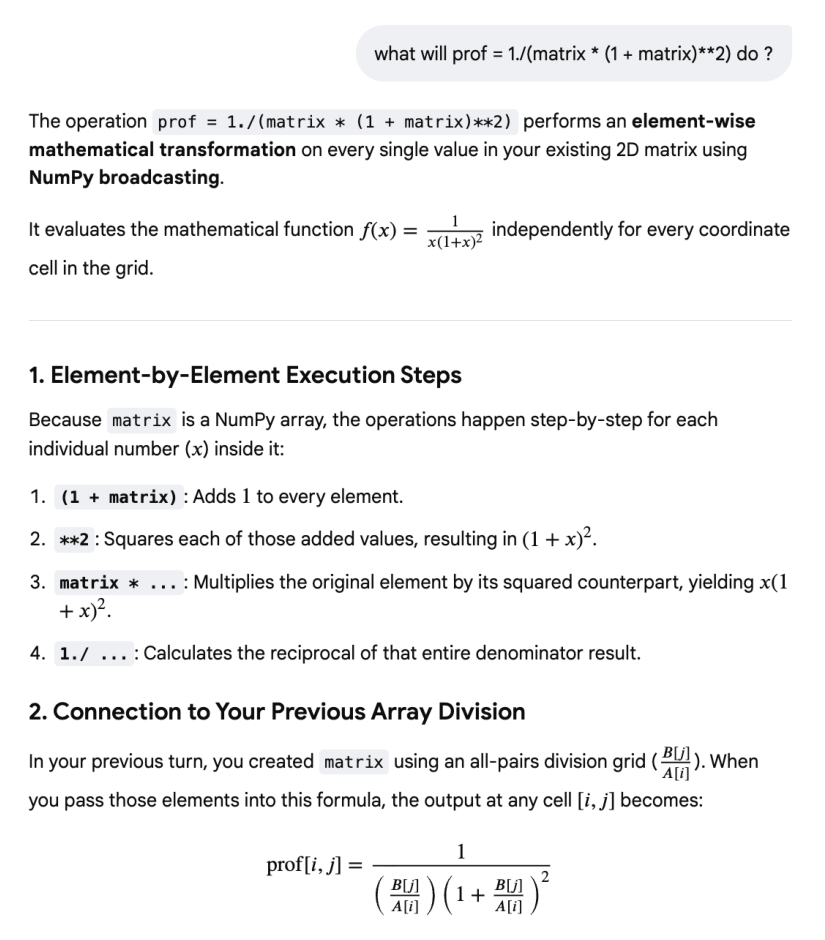

In [9]:
show_images(1, 1, images=["code_exploration/numpy_boadcasting_operation.png"], dpi=200)

So each row of variable `prof` is an NFW profile for a halo of a different mass passed in `ccl.__main__.HaloProfileHOD._usat_real`

### Plot NFW profile from CCL and compare features

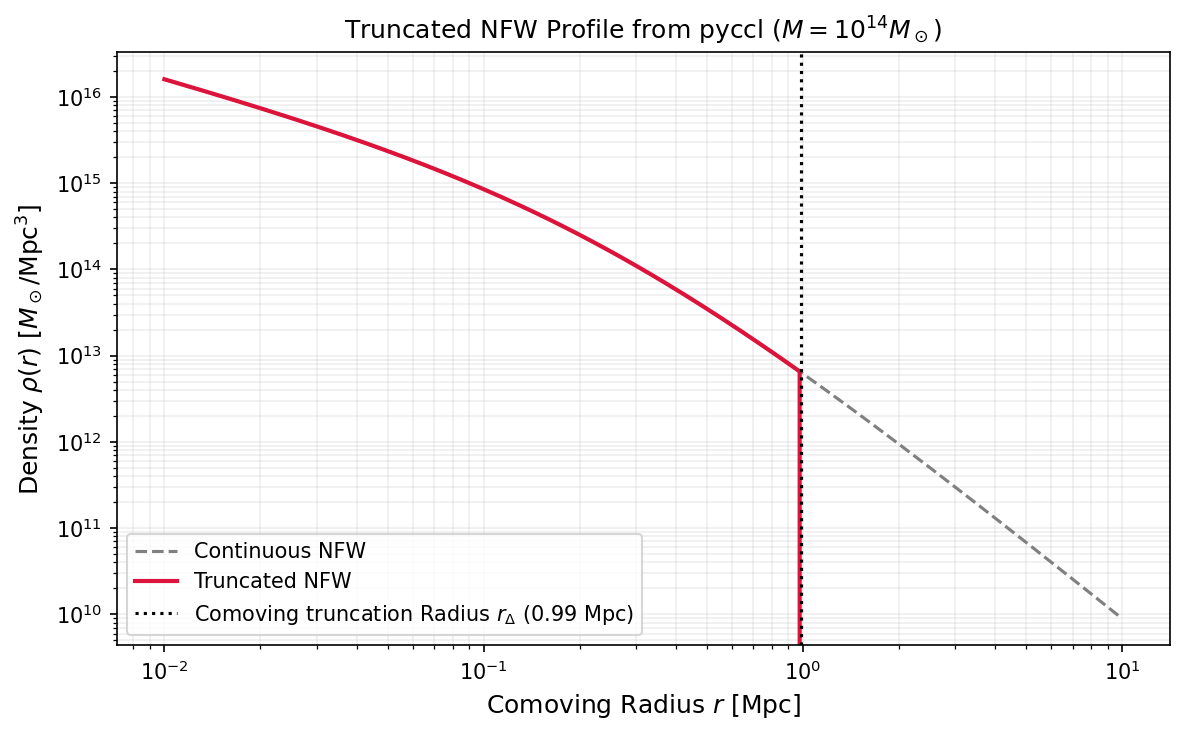

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

# 1. Initialize a vanilla LCDM cosmology object
cosmo = ccl.CosmologyVanillaLCDM()

# 2. Define halo properties
mass_def = ccl.halos.MassDef200c  # 200 times critical density definition
concentration = ccl.halos.ConcentrationDuffy08(
    mass_def=mass_def
)  # Duffy 2008 c-M relation
halo_mass = 1e14  # Halo Mass in M_sun
scale_factor = 1.0  # Redshift z = 0 (a = 1/(1+z))

# 3. Instantiate the NFW Profiles
# By default, truncated=True. We make two instances to show the truncation boundary.
nfw_truncated = ccl.halos.HaloProfileNFW(
    mass_def=mass_def, concentration=concentration, truncated=True
)

nfw_continuous = ccl.halos.HaloProfileNFW(
    mass_def=mass_def, concentration=concentration, truncated=False
)

# 4. Generate radial distance grid (comoving Mpc)
# From 0.01 Mpc to 10 Mpc: Comoving radial distance
r_grid = np.geomspace(0.01, 10.0, 200)

# 5. Compute 3D real-space densities (returns rho in units of M_sun / Mpc^3)
rho_trunc = nfw_truncated.real(cosmo, r_grid, M=halo_mass, a=scale_factor)
rho_cont = nfw_continuous.real(cosmo, r_grid, M=halo_mass, a=scale_factor)

# Calculate the comoving truncation radius (R_delta) for visual reference
r_delta = mass_def.get_radius(cosmo, M=halo_mass, a=scale_factor) / scale_factor

# 6. Plot the profiles
plt.figure(figsize=(8, 5), dpi=150)

plt.loglog(r_grid, rho_cont, label="Continuous NFW", color="gray", linestyle="--")
plt.loglog(r_grid, rho_trunc, label="Truncated NFW", color="crimson", lw=2)

# Mark the truncation boundary
plt.axvline(
    r_delta,
    color="black",
    linestyle=":",
    label=f"Comoving truncation Radius $r_\\Delta$ ({r_delta:.2f} Mpc)",
)

# Formatting
plt.title(
    f"Truncated NFW Profile from pyccl ($M = 10^{{{int(np.log10(halo_mass))}}} M_\\odot$)"
)
plt.xlabel("Comoving Radius $r$ [Mpc]", fontsize=12)
plt.ylabel("Density $\\rho(r)$ [$M_\\odot / \\mathrm{Mpc}^3$]", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()


Note 

- the concentration of the halos increase as the mass decreases, which is a well-known trend in cosmology. This means that lower-mass halos are more centrally concentrated than higher-mass halos. The concentration parameter (c) is defined as the ratio of the halo's virial radius to its scale radius, and it typically decreases with increasing halo mass. This relationship is often described by a concentration-mass relation, such as the one provided by Duffy et al. (2008), which we used in our implementation. 

- the truncation radius (R_delta) is where the density profile sharply drops to zero in the truncated NFW profile, while the continuous NFW profile extends indefinitely. The truncation radius is determined by the mass definition and cosmology, and it represents the physical boundary of the halo in the truncated model.

- The concentration of halo increase from higher to lower redshifts.

- As we'll see in future, in HOD models which alter the satellite galaxy's radius profile from the 1-halo dark matter distribution, even allow satellites to spread beyond the truncation radius. Whether this is physical or not, I need to check it.

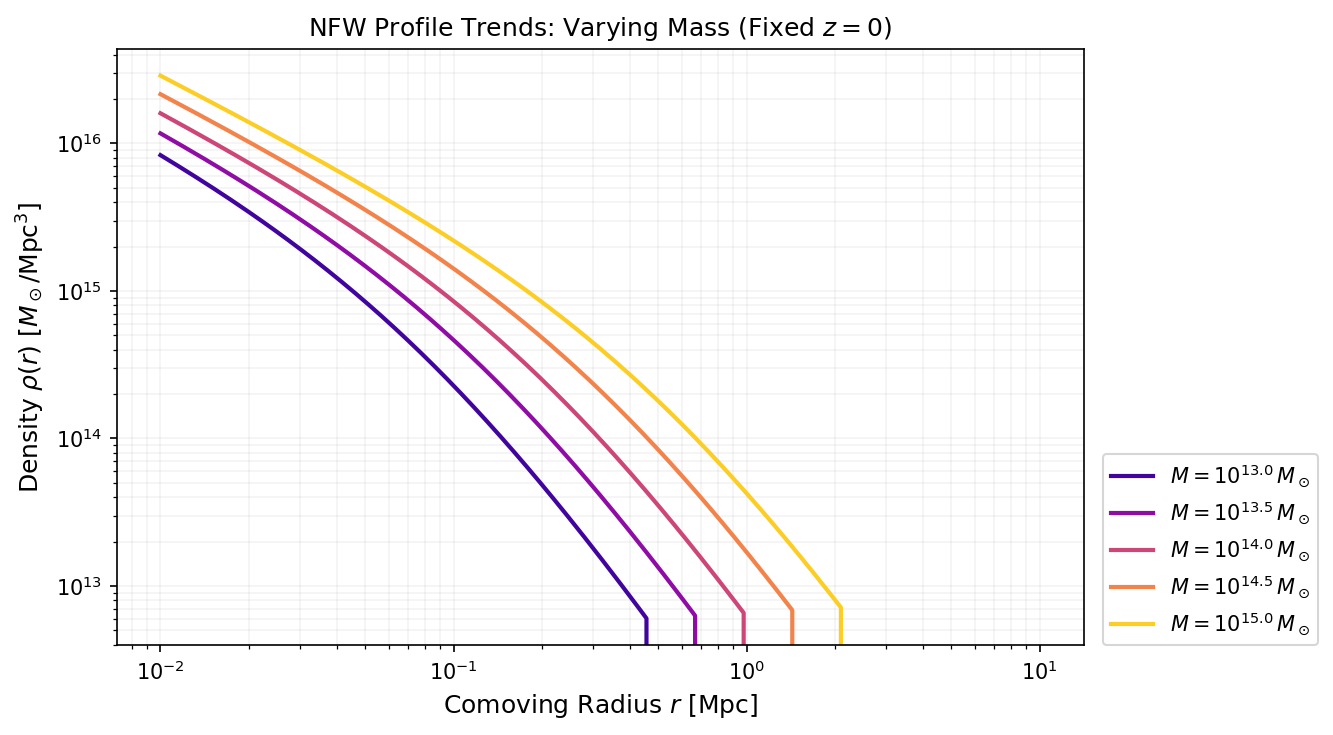

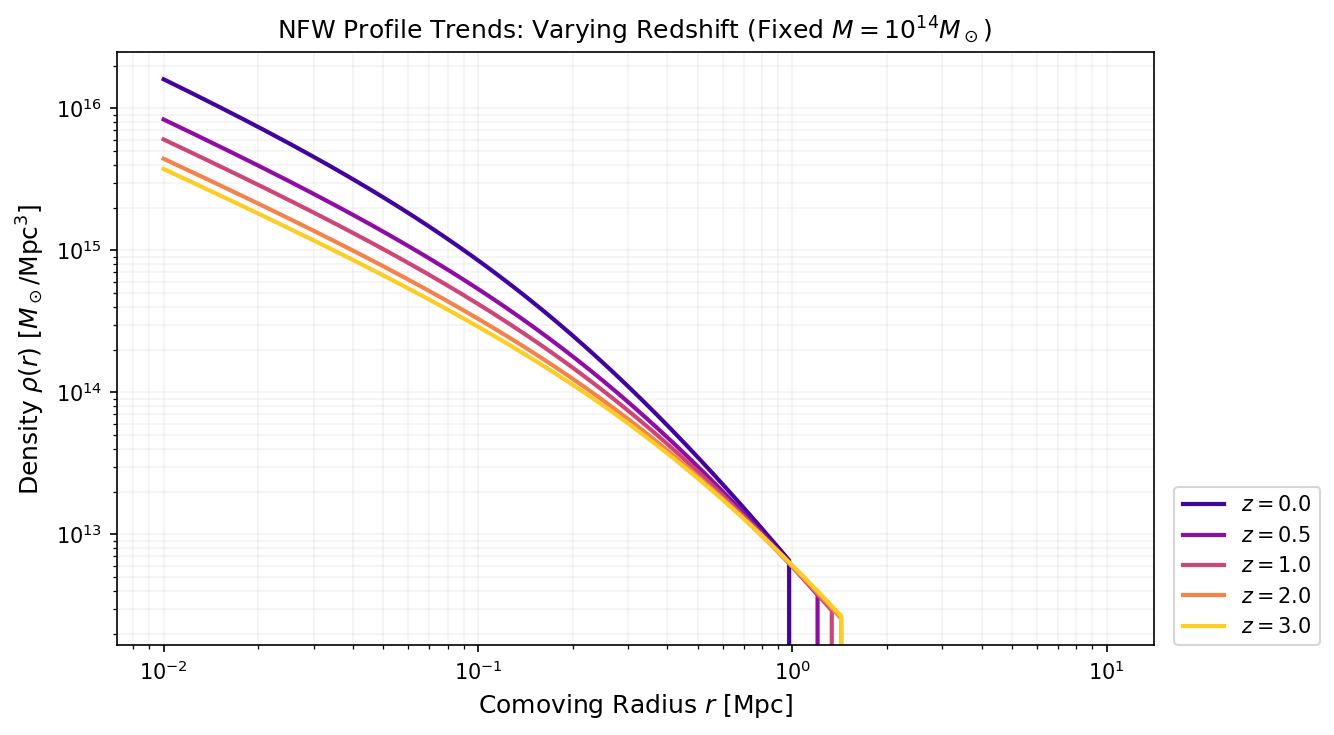

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyccl as ccl

# ==========================================
# 1. SETUP GLOBAL INITIALIZATION
# ==========================================
cosmo = ccl.CosmologyVanillaLCDM()
mass_def = ccl.halos.MassDef200c  # 200 times critical density definition
concentration = ccl.halos.ConcentrationDuffy08(mass_def=mass_def)

# Instantiate the profile (default is truncated=True)
nfw = ccl.halos.HaloProfileNFW(mass_def=mass_def, concentration=concentration)

# Radial evaluation grid (comoving Mpc)
r_grid = np.geomspace(0.01, 10.0, 200)


# ==========================================
# 2. DEFINE REUSABLE PLOTTING WRAPPER
# ==========================================
def plot_nfw_trends(r, profiles, parameters, vary_type, constant_text):
    """
    Plots a family of NFW profiles using a color gradient.
    """
    plt.figure(figsize=(9, 5), dpi=150)

    # Generate a color map gradient based on the number of steps
    colors = cm.plasma(np.linspace(0.1, 0.9, len(parameters)))

    for param, profile_data, color in zip(parameters, profiles, colors):
        # Format the label based on what is varying
        if vary_type == "mass":
            label = f"$M = 10^{{{np.log10(param):.1f}}} \\, M_\\odot$"
        else:  # redshift
            label = f"$z = {1 / param - 1:.1f}$"  # conversion from scale factor 'a'

        plt.loglog(r, profile_data, label=label, color=color, lw=2)

    # Styling and Labels
    plt.title(f"NFW Profile Trends: Varying {vary_type.capitalize()} ({constant_text})")
    plt.xlabel("Comoving Radius $r$ [Mpc]", fontsize=12)
    plt.ylabel("Density $\\rho(r)$ [$M_\\odot / \\mathrm{Mpc}^3$]", fontsize=12)
    plt.legend(loc="lower left", bbox_to_anchor=(1.02, 0.0), borderaxespad=0)
    plt.grid(True, which="both", ls="-", alpha=0.15)
    plt.tight_layout()
    plt.show()


# ==========================================
# 3. EXPERIMENT A: VARY MASS (Fixed Redshift z=0)
# ==========================================
# Define an array of target masses
mass_array = np.logspace(13, 15, 5)  # 5 halos from 10^13 to 10^15 M_sun
scale_factor_fixed = 1.0  # z = 0

mass_profiles = []
for M in mass_array:
    rho = nfw.real(cosmo, r_grid, M=M, a=scale_factor_fixed)
    mass_profiles.append(rho)

# Run the plot for Mass
plot_nfw_trends(
    r_grid, mass_profiles, mass_array, vary_type="mass", constant_text="Fixed $z = 0$"
)

# ==========================================
# 4. EXPERIMENT B: VARY REDSHIFT (Fixed Mass M=10^14)
# ==========================================
# Define an array of target redshifts converted to scale factors: a = 1/(1+z)
redshifts = np.array([0.0, 0.5, 1.0, 2.0, 3.0])
scale_factors = 1.0 / (1.0 + redshifts)
mass_fixed = 1e14

redshift_profiles = []
for a in scale_factors:
    rho = nfw.real(cosmo, r_grid, M=mass_fixed, a=a)
    redshift_profiles.append(rho)

# Run the plot for Redshift
plot_nfw_trends(
    r_grid,
    redshift_profiles,
    scale_factors,
    vary_type="redshift",
    constant_text="Fixed $M = 10^{14} M_\\odot$",
)


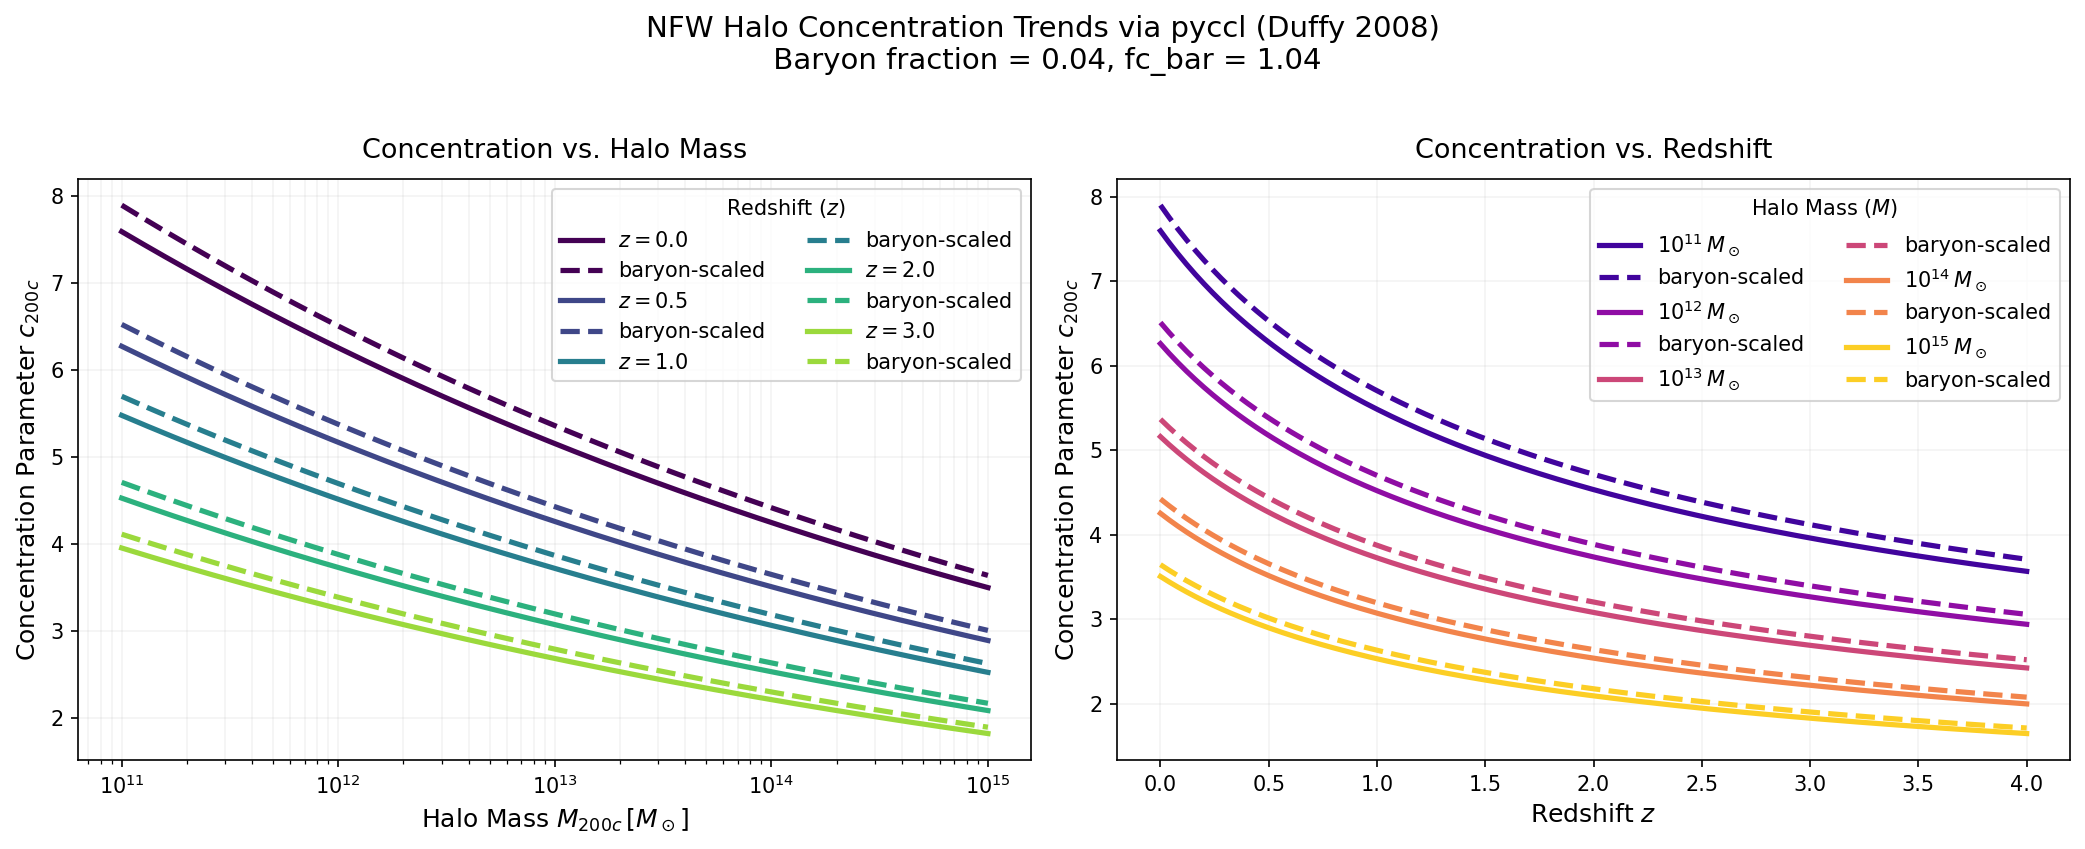

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyccl as ccl

# ==========================================
# 1. SETUP GLOBAL INITIALIZATION
# ==========================================
cosmo = ccl.CosmologyVanillaLCDM()
mass_def = ccl.halos.MassDef200c

# Use the Duffy et al. 2008 concentration-mass relation
c_model = ccl.halos.ConcentrationDuffy08(mass_def=mass_def)
bf = 0.04  # a rough baryon fraction to test the impact on concentration
c_model_bar = ccl.halos.ConcentrationDuffy08(
    mass_def=mass_def, fc_bar=1.0 + bf
)  # a scaling parameter to roughly capture the baryon fraction (if needed),
# Note, this multiplicative scaling is a very simplified way to overall alter
# the concentration. Part of this variation can be justificed to mimic baryonic
# effects on concentration. In practice, one would need a more detailed model or
# simulation-based calibration to capture the complex interplay of baryons and
# dark matter in halos. This is used in HOD models to capture the overall effect
# of baryons and non-linear DM interactions within a halo and between nearby
# halos.  In practice, the concentration-Mass relation has a big scatter as a
# function of halo mass and can significantly affect the overall matter power
# spectrum within 1-halo term and the overall clustering of matter on small
# scales.

# Create high-resolution evaluation grids
mass_grid = np.logspace(11, 15, 200)  # Mass from 10^11 to 10^15 M_sun
redshift_grid = np.linspace(0.0, 4.0, 200)  # Redshift from z=0 to z=4
scale_fact_grid = 1.0 / (1.0 + redshift_grid)

# ==========================================
# 2. INITIALIZE PLOT LAYOUT (High DPI Row)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# ------------------------------------------
# PANEL 1: Concentration vs. Mass (Varying z)
# ------------------------------------------
# Discrete redshifts to analyze
sample_redshifts = np.array([0.0, 0.5, 1.0, 2.0, 3.0])
sample_a = 1.0 / (1.0 + sample_redshifts)
colors_z = cm.viridis(np.linspace(0.0, 0.85, len(sample_redshifts)))

for z, a, color in zip(sample_redshifts, sample_a, colors_z):
    # FIXED: call the object directly -> c_model(cosmo, M, a)
    c_values = c_model(cosmo, M=mass_grid, a=a)
    c_values_bar = c_model_bar(cosmo, M=mass_grid, a=a)

    ax1.plot(mass_grid, c_values, label=f"$z = {z:.1f}$", color=color, lw=2.5)
    ax1.plot(
        mass_grid,
        c_values_bar,
        linestyle="--",
        color=color,
        lw=2.5,
        label="baryon-scaled",
    )

ax1.set_xscale("log")
ax1.set_title("Concentration vs. Halo Mass", fontsize=13, pad=10)
ax1.set_xlabel("Halo Mass $M_{200c} \\, [M_\\odot]$", fontsize=12)
ax1.set_ylabel("Concentration Parameter $c_{200c}$", fontsize=12)
ax1.legend(title="Redshift ($z$)", loc="upper right", ncol=2)
ax1.grid(True, which="both", ls="-", alpha=0.15)

# ------------------------------------------
# PANEL 2: Concentration vs. Redshift (Varying M)
# ------------------------------------------
# Discrete halo masses to analyze
sample_masses = np.logspace(11, 15, 5)  # 5 masses from 10^11 to 10^15 M_sun
colors_M = cm.plasma(np.linspace(0.1, 0.9, len(sample_masses)))

for M, color in zip(sample_masses, colors_M):
    # FIXED: call the object directly -> c_model(cosmo, M, a)
    c_values_over_a = np.array(
        [c_model(cosmo, M=M, a=a_val) for a_val in scale_fact_grid]
    )
    c_values_over_a_bar = np.array(
        [c_model_bar(cosmo, M=M, a=a_val) for a_val in scale_fact_grid]
    )

    ax2.plot(
        redshift_grid,
        c_values_over_a,
        label=f"$10^{{{np.log10(M):.0f}}} \\, M_\\odot$",
        color=color,
        lw=2.5,
    )
    ax2.plot(
        redshift_grid,
        c_values_over_a_bar,
        linestyle="--",
        color=color,
        lw=2.5,
        label="baryon-scaled",
    )

ax2.set_title("Concentration vs. Redshift", fontsize=13, pad=10)
ax2.set_xlabel("Redshift $z$", fontsize=12)
ax2.set_ylabel("Concentration Parameter $c_{200c}$", fontsize=12)
ax2.legend(title="Halo Mass ($M$)", loc="upper right", ncol=2)
ax2.grid(True, which="both", ls="-", alpha=0.15)

# ==========================================
# 3. RENDER THE COMPARISON
# ==========================================
plt.suptitle(
    f"NFW Halo Concentration Trends via pyccl (Duffy 2008)\n Baryon fraction = {bf:.2f}, fc_bar = {1.0 + bf:.2f}",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()


##### More on c-M relation:
    
    The relation is calibrated by running multiple n-body simulations for different background cosmologies. This relation is calibrated as a function of mass, redshift and other halo properties.
    It has huge intrinsic scatter, which is not reported by python modules like colossus and CCL. But these intrinsic scatter need to be accounted for when modeling an observational data in order to account for physics that impact this reltion. The origin of these physical effect can be either of astrophysical or cosmological.

Skipping Klypin 2016: Not compatible with this specific mass definition or CCL version.


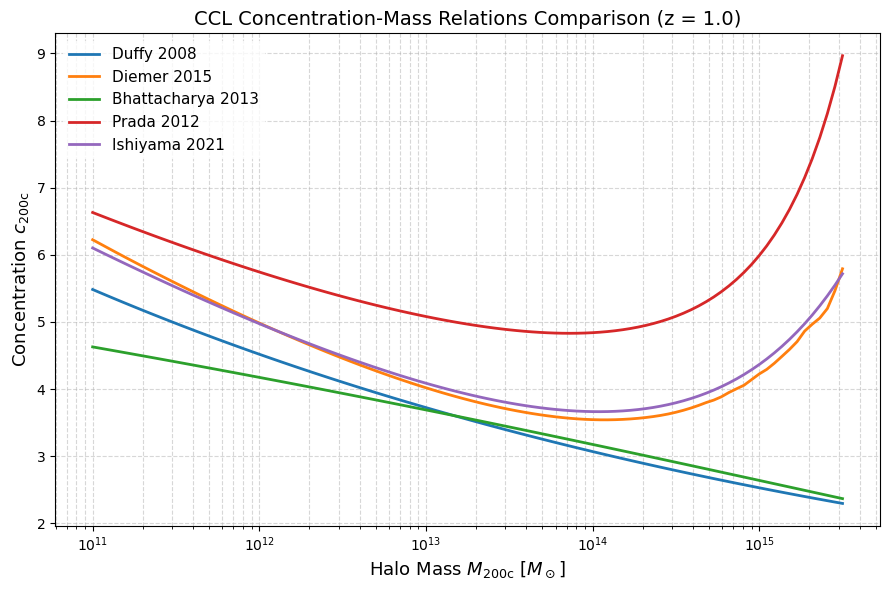

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyccl as ccl

# Define the mass range and redshift for the evaluation
# HOD modeling usually spans 10^11 to 10^15.5 solar masses
halo_masses = np.logspace(11.0, 15.5, 100)
redshift = 1.0  # Example redshift

# 3. Set up a standard Mass Definition
# We use 200 times the matter density (200m), typical for modern HOD/lensing
cosmo = ccl.CosmologyVanillaLCDM()
mass_def = ccl.halos.MassDef200c

# 4. List the concentration-mass relations available in CCL
# Note: Some relations are strictly tied to specific mass definitions
cm_relations = {
    "Duffy 2008": ccl.halos.ConcentrationDuffy08,  # defined for both critical and mean S.O. overdensity
    "Diemer 2015": ccl.halos.ConcentrationDiemer15,  # defined only for critical S.O. overdensity
    "Bhattacharya 2013": ccl.halos.ConcentrationBhattacharya13,  # defined for both critical and mean S.O. overdensity
    "Prada 2012": ccl.halos.ConcentrationPrada12,  # defined only for 200 times the critical S.O
    "Klypin 2016": ccl.halos.ConcentrationKlypin11,  # defined only for virial S.O
    "Ishiyama 2021": ccl.halos.ConcentrationIshiyama21,  # defined only for critical S.O. overdensity
}

# 5. Compute and plot each relation
plt.figure(figsize=(9, 6))

for name, RelationClass in cm_relations.items():
    try:
        # Instantiate the CCL concentration object
        # Passing mass_def ensures all curves are evaluated under the same definition
        c_model = RelationClass(mass_def=mass_def)

        # Calculate concentrations
        concentrations = c_model(cosmo, halo_masses, a=1.0 / (1.0 + redshift))

        # Plot the curve
        plt.plot(halo_masses, concentrations, label=name, lw=2)

    except Exception as e:
        # Some relations in older/newer versions of CCL might have specific mass_def constraints
        print(
            f"Skipping {name}: Not compatible with this specific mass definition or CCL version."
        )

# 6. Formatting the plot for scientific presentation
plt.xscale("log")
plt.yscale("linear")
plt.xlabel(r"Halo Mass $M_{200\rm c} \ [M_\odot]$", fontsize=13)
plt.ylabel(r"Concentration $c_{200\rm c}$", fontsize=13)
plt.title(f"CCL Concentration-Mass Relations Comparison (z = {redshift})", fontsize=14)
plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

# Show or save the plot
plt.show()


Convert masses to mean backgroud overdensity terms, use `translator` object

$c_{200c} \rightarrow c_{200m}$


# The below plot has issues. Couldn't correctly convert c-M relation from M200c to M200m, for those c-M objects that had only 200c definition coded.

Duffy08
Diemer15
Bhattacharya13
Prada12
Skipping Klypin 2016: Not compatible with this specific mass definition or CCL version.ConcentrationKlypin11 is not defined for 200c masses and this requirement cannot be relaxed.
Ishiyama21


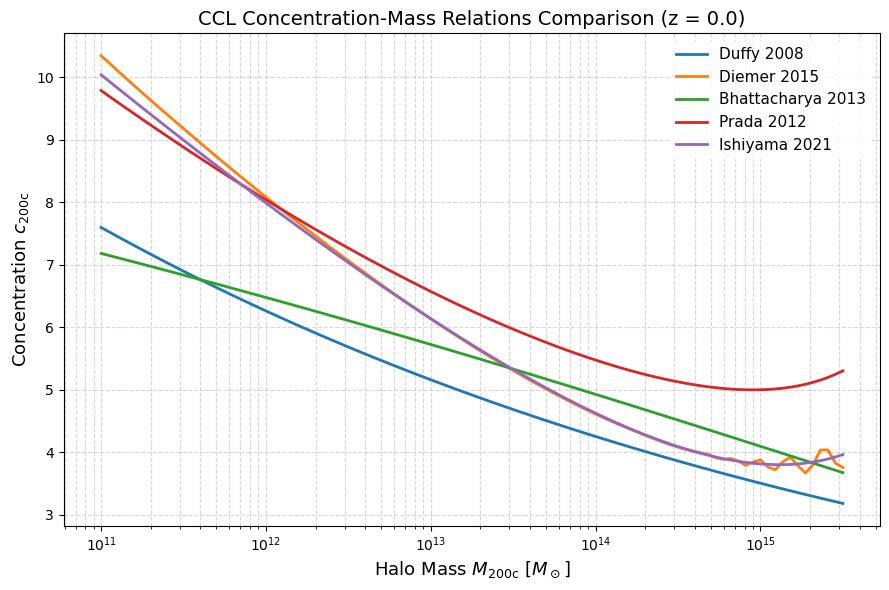

In [57]:
# Define the mass range and redshift for the evaluation
# HOD modeling usually spans 10^11 to 10^15.5 solar masses
halo_masses = np.logspace(11.0, 15.5, 100)
redshift = 0.0  # Example redshift

# 3. Set up a standard Mass Definition
# We use 200 times the matter density (200m), typical for modern HOD/lensing
cosmo = ccl.CosmologyVanillaLCDM()
mass_def_200c = ccl.halos.MassDef200c
mass_def_200m = ccl.halos.MassDef200m

# 4. List the concentration-mass relations available in CCL
# Note: Some relations are strictly tied to specific mass definitions
cm_relations = {
    "Duffy 2008": ccl.halos.ConcentrationDuffy08,  # defined for both critical and mean S.O. overdensity
    "Diemer 2015": ccl.halos.ConcentrationDiemer15,  # defined only for critical S.O. overdensity
    "Bhattacharya 2013": ccl.halos.ConcentrationBhattacharya13,  # defined for both critical and mean S.O. overdensity
    "Prada 2012": ccl.halos.ConcentrationPrada12,  # defined only for 200 times the critical S.O
    "Klypin 2016": ccl.halos.ConcentrationKlypin11,  # defined only for virial S.O
    "Ishiyama 2021": ccl.halos.ConcentrationIshiyama21,  # defined only for critical S.O. overdensity
}

# 5. Compute and plot each relation
plt.figure(figsize=(9, 6))

for name, RelationClass in cm_relations.items():
    try:
        # Instantiate the CCL concentration object
        # Passing mass_def ensures all curves are evaluated under the same definition
        c_model = RelationClass(mass_def=mass_def_200c)
        print(RelationClass.name)
        translator = ccl.halos.mass_translator(
            mass_in=mass_def_200c,
            mass_out=mass_def_200m,
            concentration=RelationClass.name,
        )
        # Calculate concentrations based on
        concentrations = c_model(cosmo, halo_masses, a=1.0 / (1.0 + redshift))

        # save the masses to plot in 200m definition for the x-axis
        M200m = translator(cosmo, halo_masses, a=1.0 / (1.0 + redshift))

        # !!!!!!!!!!! You're plotting c-M relation of 200c and not 200m. The y-values need to be copmputed within smaller radii of 200m.
        # Solve this issue in future. Or ask CCL developers to code this up.
        plt.plot(halo_masses, concentrations, label=name, lw=2)

    except Exception as e:
        # Some relations in older/newer versions of CCL might have specific mass_def constraints
        print(
            f"Skipping {name}: Not compatible with this specific mass definition or CCL version."
            f"{e}"
        )

# 6. Formatting the plot for scientific presentation
plt.xscale("log")
plt.yscale("linear")
plt.xlabel(r"Halo Mass $M_{200\rm c} \ [M_\odot]$", fontsize=13)
plt.ylabel(r"Concentration $c_{200\rm c}$", fontsize=13)
plt.title(f"CCL Concentration-Mass Relations Comparison (z = {redshift})", fontsize=14)
plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

# Show or save the plot
plt.show()


### Which c-M relation to use for HOD modeling? These vary so much and can significantly affect the 1-halo term and overall clustering on small scales.

/tmp/ipykernel_3510920/1183665724.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1', len(cm_relations))


Skipping Klypin 2016 at z=0.0: ConcentrationKlypin11 is not defined for 200c masses and this requirement cannot be relaxed.
Skipping Klypin 2016 at z=0.5: ConcentrationKlypin11 is not defined for 200c masses and this requirement cannot be relaxed.
Skipping Klypin 2016 at z=1.0: ConcentrationKlypin11 is not defined for 200c masses and this requirement cannot be relaxed.
Skipping Klypin 2016 at z=1.5: ConcentrationKlypin11 is not defined for 200c masses and this requirement cannot be relaxed.


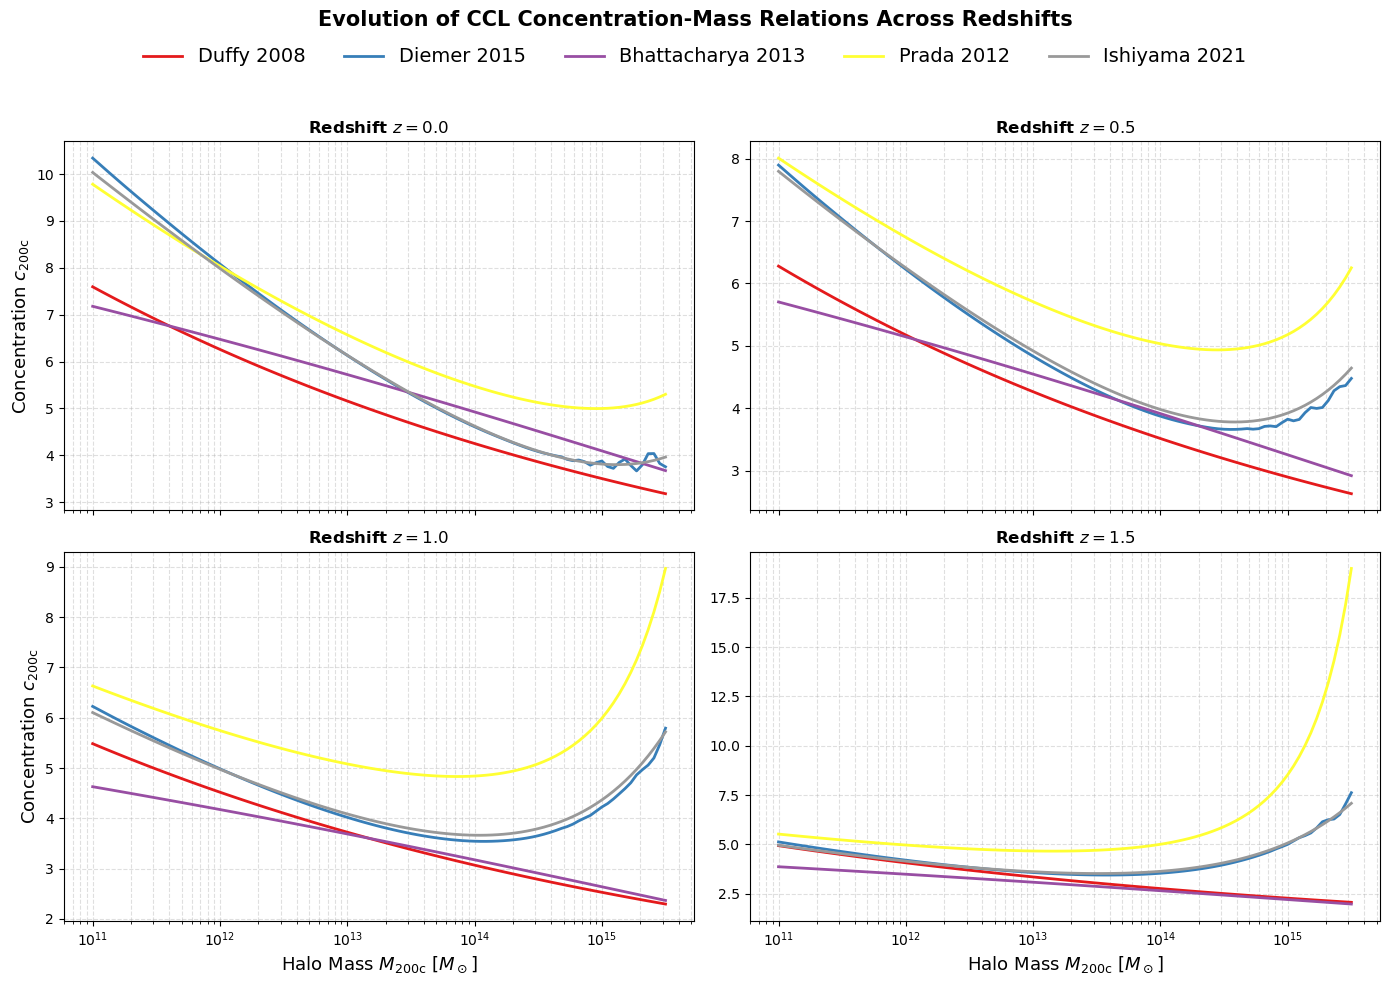

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyccl as ccl

# 1. Setup the evaluation ranges and cosmology
halo_masses = np.logspace(11.0, 15.5, 100)  # Msun
redshifts = [0.0, 0.5, 1.0, 1.5]  # The targeted list of redshifts
cosmo = ccl.CosmologyVanillaLCDM()

# Initialize the target mass definition object
mass_def = ccl.halos.MassDef200c

# 2. List the concentration-mass relations available in CCL
cm_relations = {
    "Duffy 2008": ccl.halos.ConcentrationDuffy08,
    "Diemer 2015": ccl.halos.ConcentrationDiemer15,
    "Bhattacharya 2013": ccl.halos.ConcentrationBhattacharya13,
    "Prada 2012": ccl.halos.ConcentrationPrada12,
    "Klypin 2016": ccl.halos.ConcentrationKlypin11,  # Note: Fixed class name suffix to 16
    "Ishiyama 2021": ccl.halos.ConcentrationIshiyama21,
}

# 3. Dynamically assign a fixed color to each model for cross-panel tracking
colors = cm.get_cmap("Set1", len(cm_relations))
model_colors = {name: colors(i) for i, name in enumerate(cm_relations.keys())}

# 4. Initialize a multi-panel subplot grid
# We create a 2x2 grid based on our 4 sample redshifts
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()  # Flatten the 2D array into a 1D list for easy looping

# 5. Nested loop over both Redshifts and Models
for ax, z in zip(axes, redshifts):
    a_scale = 1.0 / (1.0 + z)

    for name, RelationClass in cm_relations.items():
        try:
            # Instantiate the relation model
            c_model = RelationClass(mass_def=mass_def)

            # Compute concentrations for the current redshift slice
            concentrations = c_model(cosmo, halo_masses, a=a_scale)

            # Plot using the model's assigned tracking color
            ax.plot(
                halo_masses, concentrations, label=name, color=model_colors[name], lw=2
            )

        except Exception as e:
            print(f"Skipping {name} at z={z}: {e}")

    # Individual panel formatting
    ax.set_xscale("log")
    ax.set_title(f"Redshift $z = {z}$", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", ls="--", alpha=0.4)

# Set labels on the outer boundaries using shared axis positions
for i in [2, 3]:  # Bottom row plots
    axes[i].set_xlabel(r"Halo Mass $M_{200\rm c} \ [M_\odot]$", fontsize=13)
for i in [0, 2]:  # Left column plots
    axes[i].set_ylabel(r"Concentration $c_{200\rm c}$", fontsize=13)

# Place a single unified legend at the top of the entire figure window
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=len(cm_relations),
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=14,
)

fig.suptitle(
    "Evolution of CCL Concentration-Mass Relations Across Redshifts",
    fontsize=15,
    y=0.98,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.92])  # Make room for the top legend block

# Show or save the multi-panel plot
plt.show()
